In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [41]:
# Set display options for better viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 50)

In [42]:
# Load Data
print("Loading data...")
demographics = pd.read_csv('data/demographics.csv')
current_commitments = pd.read_csv('data/current_commitments.csv')
prior_commitments = pd.read_csv('data/prior_commitments.csv')

print(f"\nDemographics shape: {demographics.shape}")
print(f"Current commitments shape: {current_commitments.shape}")
print(f"Prior commitments shape: {prior_commitments.shape}")

Loading data...


/var/folders/qq/2xq_hbb10j75t18jqwpwnfzh0000gn/T/ipykernel_10569/3625507257.py:4: DtypeWarning: Columns (7,22,23,24,25,26,27,28,29,30,31,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  current_commitments = pd.read_csv('data/current_commitments.csv')



Demographics shape: (95476, 13)
Current commitments shape: (369125, 34)
Prior commitments shape: (191436, 13)


In [43]:
print("\nFirst 5 rows:")
demographics.head()


First 5 rows:


,CDCNo,Ethnicity,Controlling Offense,Description,Offense Begin Date,Offense End Date,Controlling Case Number,Controlling Case Sentencing County,Sentence Type,Aggregate Sentence in Months,Offense Category,EPRD/MEPD Month and Year,Current Location
0,2cf2a233c4,Black,VC10851(a),Vehicle Theft,2022-12-07,2022-12-07,FVI22003547,San Bernardino,Second Striker,32,Property Crimes,APR24,Central California Women's Facility
1,5a72696541,White,PC187 2nd,Murder 2nd,2012-09-18,2012-09-18,12F06402,Sacramento,Life with Parole,360,Crimes Against Persons,NOV33,Central California Women's Facility
2,7d608b6a4c,White,PC187 2nd,Murder 2nd,2010-05-18,2010-05-18,CM032513,Butte,Life with Parole,300,Crimes Against Persons,SEP28,Central California Women's Facility
3,39c1bc8c2f,Other,PC459,Burglary 1st,1998-01-20,1998-01-20,CM010387,Butte,Third Striker,348,Property Crimes,NOV22,California Institution for Women
4,220f2cdfc5,Black,PC187,Murder 1st,2017-03-21,2017-03-21,BA455966,Los Angeles,Life with Parole,312,Crimes Against Persons,MAY35,California Institution for Women


In [24]:
# Missing values 
print("\nMissing values per column:")
print(demographics.isna().sum())


Missing values per column:
CDCNo                                     0
Ethnicity                                 0
Controlling Offense                       1
Description                               1
Offense Begin Date                        1
Offense End Date                          1
Controlling Case Number               25356
Controlling Case Sentencing County        0
Sentence Type                             0
Aggregate Sentence in Months              0
Offense Category                          0
EPRD/MEPD Month and Year                  1
Current Location                          0
dtype: int64


In [25]:
# Unique values analysis
for col in demographics.columns:
    if demographics[col].nunique() < 1000:
        print(f"Number of unique values in {col}: {demographics[col].nunique()}")

Number of unique values in Ethnicity: 28
Number of unique values in Controlling Offense: 483
Number of unique values in Description: 528
Number of unique values in Controlling Case Sentencing County: 57
Number of unique values in Sentence Type: 7
Number of unique values in Offense Category: 4
Number of unique values in Current Location: 36


In [26]:
# Convert date columns to datetime
print("\nConverting date columns...")
demographics['Offense Begin Date'] = pd.to_datetime(demographics['Offense Begin Date'], errors='coerce')
demographics['Offense End Date'] = pd.to_datetime(demographics['Offense End Date'], errors='coerce')

demographics[['Offense Begin Date', 'Offense End Date']].head()


Converting date columns...


,Offense Begin Date,Offense End Date
0,2022-12-07,2022-12-07
1,2012-09-18,2012-09-18
2,2010-05-18,2010-05-18
3,1998-01-20,1998-01-20
4,2017-03-21,2017-03-21


In [27]:
# Check date ranges
print("\nDate ranges:")
print(f"Offense Begin Date range: {demographics['Offense Begin Date'].min()} to {demographics['Offense Begin Date'].max()}")
print(f"Offense End Date range: {demographics['Offense End Date'].min()} to {demographics['Offense End Date'].max()}")


Date ranges:
Offense Begin Date range: 1964-03-21 00:00:00 to 2023-12-09 00:00:00
Offense End Date range: 1964-03-21 00:00:00 to 2027-02-10 00:00:00


In [28]:
# Check for illogical dates (end before begin)
date_logic_check = demographics[demographics['Offense End Date'] < demographics['Offense Begin Date']]
print(f"\nNumber of records with end date before begin date: {len(date_logic_check)}")


Number of records with end date before begin date: 0


In [68]:
# Check for illogical sentence times
count = (demographics['Aggregate Sentence in Months'] > 100000).sum()
print(f"Number of sentences greater than 100000 months: {count}")

Number of sentences greater than 100000 months: 650


^^ wtf lol

In [55]:
# Merge demographics with current commitments on ccdno
merged = pd.merge(demographics, current_commitments, on='CDCNo', how='left')

# Examine the sentence values
print("\nComparison of sentence values:")
print(merged[['Aggregate Sentence in Months', 'Sentence From Abstract of Judgement']].head())


Comparison of sentence values:
   Aggregate Sentence in Months Sentence From Abstract of Judgement
0                            32                    2 Years 8 Months
1                           360                    Life with Parole
2                           360                    Life with Parole
3                           300                    Life with Parole
4                           348                    1 Years 4 Months


In [57]:
# Sort from high to low by aggregate sentence in months
sorted_merged = merged.sort_values('Aggregate Sentence in Months', ascending=False)

# Display the top rows with the longest sentences
sorted_merged[['Aggregate Sentence in Months', 'Sentence From Abstract of Judgement']].head()

,Aggregate Sentence in Months,Sentence From Abstract of Judgement
120256,1000000,Condemned
56886,1000000,Condemned
56953,1000000,Condemned
56952,1000000,Condemned
56951,1000000,Condemned


In [71]:
sorted_merged['Sentence From Abstract of Judgement'].unique()

array(['Condemned', 'Life with Parole', 'Life w/o Parole', '11 Years',
       '5 Years', '4 Years', '3 Years', '42 Years', '34 Years 4 Months',
       '40 Years', '6 Years', '9 Years', '19 Years 8 Months',
       '1 Years 8 Months', '2 Years', '56 Years', '2 Years 8 Months',
       '17 Years', '22 Years', '1 Years', '53 Years 6 Months', '13 Years',
       '1 Years 4 Months', '23 Years 8 Months', '23 Years', '8 Years',
       nan, '20 Years 4 Months', '14 Years', '58 Years 4 Months',
       '75 Years 8 Months', '7 Years', '51 Years', '12 Years', '33 Years',
       '1503 Years', '10 Years', '15 Years', '16 Years 8 Months',
       '10 Years 8 Months', '32 Months', '3 Years 8 Months', '18 Years',
       '25 Years', '49 Years', '14 Years 4 Months', '31 Years 4 Months',
       '20 Years', '8 Months', '12 Years 8 Months', '38 Years 8 Months',
       '32 Years', '13 Years 4 Months', '9 Years 8 Months',
       '8 Years 8 Months', '46 Years 4 Months', '19 Years',
       '10 Years 4 Months', '16 

In [73]:
def encode_sentence(sentence):
    if pd.isna(sentence):
        return np.nan
    
    # Handle special cases first
    if 'Condemned' in sentence:
        return -1  # Special code for death penalty
    elif 'Life' in sentence:
        if 'w/o' in sentence:  # Life without parole
            return -2
        else:  # Life with parole
            return -3
    
    # Initialize total months
    total_months = 0
    
    # Split into components
    parts = sentence.split()
    
    # Process each part
    i = 0
    while i < len(parts):
        if parts[i].isdigit():
            value = int(parts[i])
            if i+1 < len(parts):
                unit = parts[i+1].lower()
                if 'year' in unit:
                    total_months += value * 12
                    i += 2
                elif 'month' in unit:
                    total_months += value
                    i += 2
                else:
                    i += 1
            else:
                total_months += value * 12
                i += 1
        else:
            i += 1
    
    return total_months

# Apply encoding
current_commitments['Encoded Sentence'] = current_commitments['Sentence From Abstract of Judgement'].apply(encode_sentence)

# Create a mapping for categorical encoding if needed
sentence_mapping = {
    'Condemned': 'Death Penalty',
    'Life with Parole': 'Life with Parole',
    'Life w/o Parole': 'Life w/o Parole'
}

def categorical_encode(sentence):
    if pd.isna(sentence):
        return np.nan
    for key in sentence_mapping:
        if key in sentence:
            return sentence_mapping[key]
    return 'fixed_term'

current_commitments['Categorical Sentence'] = current_commitments['Sentence From Abstract of Judgement'].apply(categorical_encode)

print(current_commitments[['Sentence From Abstract of Judgement', 'Encoded Sentence', 'Categorical Sentence']].head(20))

   Sentence From Abstract of Judgement  Encoded Sentence Categorical Sentence
0                     2 Years 8 Months              32.0           fixed_term
1                     Life with Parole              -3.0     Life with Parole
2                     Life with Parole              -3.0     Life with Parole
3                     Life with Parole              -3.0     Life with Parole
4                     1 Years 4 Months              16.0           fixed_term
5                              4 Years              48.0           fixed_term
6                              3 Years              36.0           fixed_term
7                     Life with Parole              -3.0     Life with Parole
8                     Life with Parole              -3.0     Life with Parole
9                     Life with Parole              -3.0     Life with Parole
10                    Life with Parole              -3.0     Life with Parole
11                    Life with Parole              -3.0     Lif

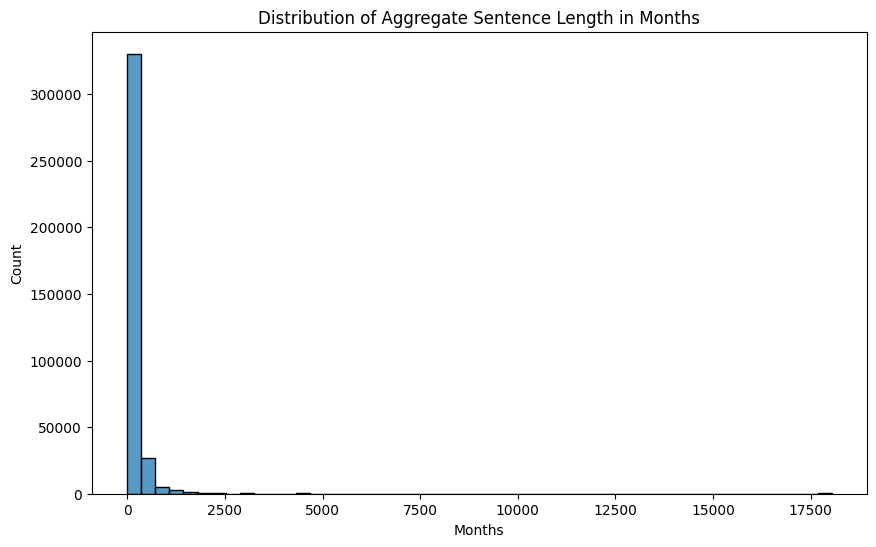

In [74]:
# Visualize Sentence Length Distribution
plt.figure(figsize=(10, 6))
sns.histplot(current_commitments['Encoded Sentence'], bins=50)
plt.title('Distribution of Aggregate Sentence Length in Months')
plt.xlabel('Months')
plt.ylabel('Count')
plt.show()

In [76]:
long_sentences = current_commitments[current_commitments['Encoded Sentence'] > 17500]
long_sentences

,CDCNo,Sentencing County,Case Number,Sentence From Abstract of Judgement,Offense,Offense Description,Offense Category,In-prison,Offense Begin Date,Offense End Date,Offense Time with Enhancement,Relationship,Off_Enh1,Off_Enh_Desc1,Off_Enh2,Off_Enh_Desc2,Off_Enh3,Off_Enh_Desc3,Off_Enh4,Off_Enh_Desc4,Off_Enh5,Off_Enh_Desc5,Off_Enh6,Off_Enh_Desc6,Off_Enh7,Off_Enh_Desc7,Off_Enh8,Off_Enh_Desc8,Off_Enh9,Off_Enh_Desc9,Off_Enh10,Off_Enh_Desc10,Off_Enh11,Off_Enh_Desc11,Encoded Sentence,Categorical Sentence
275113,3928565b3b,Fresno,NaN,1503 Years,PC288a(c)(2)(A),Oral Cop With Force/Violence/Fear of Immediate...,Crimes Against Persons,NaN,2011-12-31,2011-12-31 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18036.0,fixed_term
275114,3928565b3b,Fresno,NaN,1503 Years,PC261(a)(2),Rape w/Force/Violence/Fear of Bodily Injury,Crimes Against Persons,NaN,2013-05-31,2013-05-31 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18036.0,fixed_term
275115,3928565b3b,Fresno,NaN,1503 Years,PC261(a)(2),Rape w/Force/Violence/Fear of Bodily Injury,Crimes Against Persons,NaN,2012-11-09,2012-11-09 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18036.0,fixed_term
275116,3928565b3b,Fresno,NaN,1503 Years,PC261(a)(2),Rape w/Force/Violence/Fear of Bodily Injury,Crimes Against Persons,NaN,2012-10-29,2012-10-29 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18036.0,fixed_term
275117,3928565b3b,Fresno,NaN,1503 Years,PC261(a)(2),Rape w/Force/Violence/Fear of Bodily Injury,Crimes Against Persons,NaN,2012-10-18,2012-10-18 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18036.0,fixed_term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275294,3928565b3b,Fresno,NaN,1503 Years,PC261(a)(2),Rape w/Force/Violence/Fear of Bodily Injury,Crimes Against Persons,NaN,2009-09-30,2009-09-30 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18036.0,fixed_term
275295,3928565b3b,Fresno,NaN,1503 Years,PC261(a)(2),Rape w/Force/Violence/Fear of Bodily Injury,Crimes Against Persons,NaN,2009-08-31,2009-08-31 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18036.0,fixed_term
275296,3928565b3b,Fresno,NaN,1503 Years,PC261(a)(2),Rape w/Force/Violence/Fear of Bodily Injury,Crimes Against Persons,NaN,2009-07-31,2009-07-31 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18036.0,fixed_term
275297,3928565b3b,Fresno,NaN,1503 Years,PC261(a)(2),Rape w/Force/Violence/Fear of Bodily Injury,Crimes Against Persons,NaN,2009-06-30,2009-06-30 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18036.0,fixed_term


In [78]:
long_sentences_2 = current_commitments[
    (current_commitments['Encoded Sentence'] > 2500) & 
    (current_commitments['Encoded Sentence'] < 17500)
]

long_sentences_2

,CDCNo,Sentencing County,Case Number,Sentence From Abstract of Judgement,Offense,Offense Description,Offense Category,In-prison,Offense Begin Date,Offense End Date,Offense Time with Enhancement,Relationship,Off_Enh1,Off_Enh_Desc1,Off_Enh2,Off_Enh_Desc2,Off_Enh3,Off_Enh_Desc3,Off_Enh4,Off_Enh_Desc4,Off_Enh5,Off_Enh_Desc5,Off_Enh6,Off_Enh_Desc6,Off_Enh7,Off_Enh_Desc7,Off_Enh8,Off_Enh_Desc8,Off_Enh9,Off_Enh_Desc9,Off_Enh10,Off_Enh_Desc10,Off_Enh11,Off_Enh_Desc11,Encoded Sentence,Categorical Sentence
18283,27b41c1ba1,Sacramento,NaN,322 Years,PC289(a),Penetration W/Foreign Object,Crimes Against Persons,NaN,1987-06-10,1988-06-23 00:00:00,11 Years 0 Months,Consecutive,PC12022.3(a),USE FARM/DWPN SEX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3864.0,fixed_term
18284,27b41c1ba1,Sacramento,NaN,322 Years,PC261(2),RAPE/RESIST F/V,Crimes Against Persons,NaN,1987-06-10,1988-06-23 00:00:00,11 Years 0 Months,Consecutive,PC12022.3(a),USE FARM/DWPN SEX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3864.0,fixed_term
18285,27b41c1ba1,Sacramento,NaN,322 Years,PC261(2),RAPE/RESIST F/V,Crimes Against Persons,NaN,1987-08-13,1987-09-07 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3864.0,fixed_term
18287,27b41c1ba1,Sacramento,NaN,322 Years,PC288a(c),Oral Copulation With Force,Crimes Against Persons,NaN,1987-06-10,1988-06-23 00:00:00,11 Years 0 Months,Consecutive,PC12022.3(a),USE FARM/DWPN SEX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3864.0,fixed_term
18288,27b41c1ba1,Sacramento,NaN,322 Years,PC288a(c),Oral Copulation With Force,Crimes Against Persons,NaN,1987-06-10,1988-06-23 00:00:00,11 Years 0 Months,Consecutive,PC12022.3(a),USE FARM/DWPN SEX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3864.0,fixed_term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325230,e51a318366,Los Angeles,NaN,284 Years,PC261(a)(2),Rape w/Force/Violence/Fear Minor 14 or older,Crimes Against Persons,NaN,2016-03-01,2016-12-31 00:00:00,9 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3408.0,fixed_term
325231,e51a318366,Los Angeles,NaN,284 Years,PC288a(c)(2)(C),Oral Cop W/Force/Violence/Fear Victim Minor 14+,Crimes Against Persons,NaN,2016-03-01,2018-10-12 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3408.0,fixed_term
325232,e51a318366,Los Angeles,NaN,284 Years,PC288a(c)(2)(C),Oral Cop W/Force/Violence/Fear Victim Minor 14+,Crimes Against Persons,NaN,2016-03-01,2018-10-12 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3408.0,fixed_term
325233,e51a318366,Los Angeles,NaN,284 Years,PC288a(c)(2)(C),Oral Cop W/Force/Violence/Fear Victim Minor 14+,Crimes Against Persons,NaN,2016-03-01,2018-10-12 00:00:00,8 Years 0 Months,Consecutive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3408.0,fixed_term
